<a href="https://colab.research.google.com/github/Prajwal-Luitel/Twitter-Sentiment-Analysis/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
!pip install kagglehub[pandas-datasets]

# Importing the Dataset
### Link: https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis/data

In [23]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
train_path = "twitter_training.csv"
vald_path = "twitter_validation.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jp797498e/twitter-entity-sentiment-analysis",
  train_path,
  pandas_kwargs={"header": None}, # Add "compression": "zip" when running locally
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
First 5 records:       0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [24]:
df.columns=['id','information','label','tweet']
df.head()

,id,information,label,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


# EDA

## Number of Null Values in each column

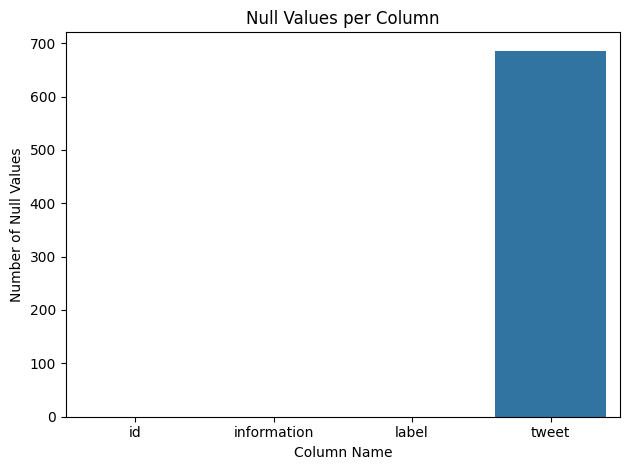

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count nulls per column
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ['column', 'null_count']
# Plot null counts
sns.barplot(
    data=null_counts,
    x='column',
    y='null_count',
)
plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.title('Null Values per Column')
plt.tight_layout()
plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           74682 non-null  int64 
 1   information  74682 non-null  object
 2   label        74682 non-null  object
 3   tweet        73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


### Removing Null Values

In [27]:
df.dropna(inplace=True)

## Number of each sentiment class

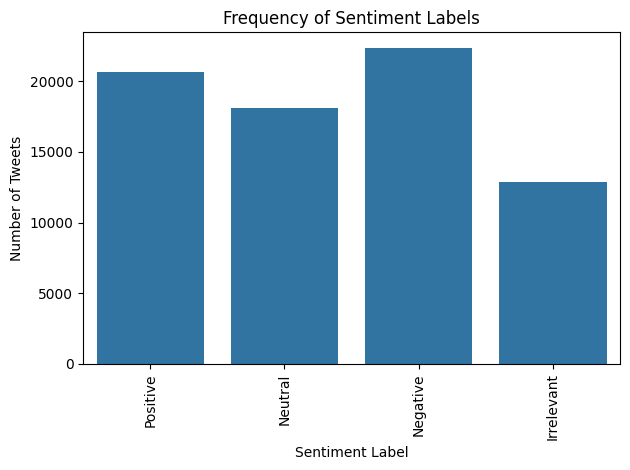

In [28]:
sns.countplot(data=df, x="label")
plt.xticks(rotation=90)
plt.title("Frequency of Sentiment Labels")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()


## Distribution of tweets per Branch and Label

In [29]:
plot=df.groupby(by=["information","label"]).count().reset_index()
plot.head()

,information,label,id,tweet
0,Amazon,Irrelevant,186,186
1,Amazon,Negative,575,575
2,Amazon,Neutral,1207,1207
3,Amazon,Positive,308,308
4,ApexLegends,Irrelevant,192,192


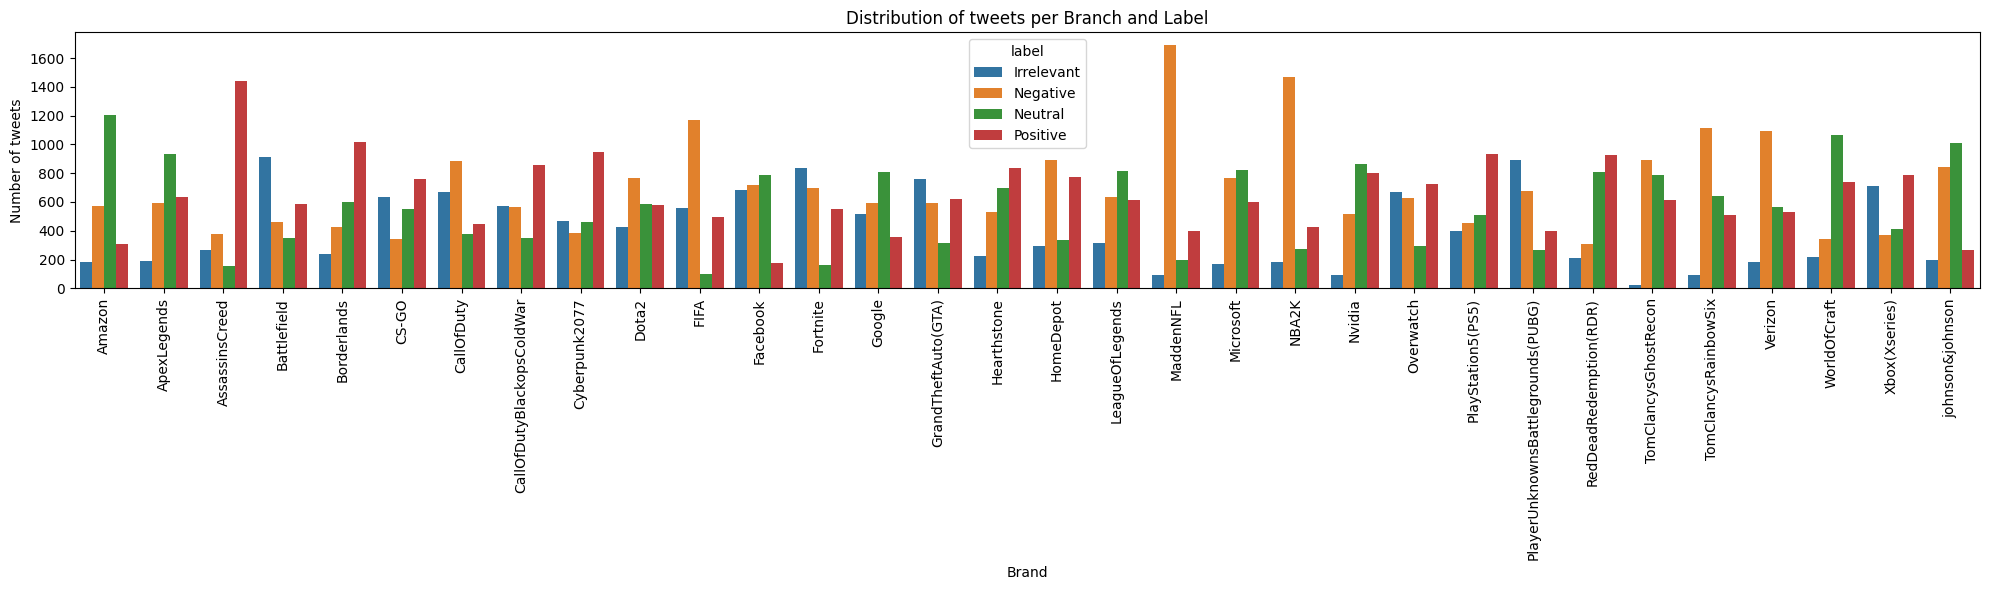

In [30]:
#Figure of comparison per label
plt.figure(figsize=(20,6))
sns.barplot(data=plot,x="information",y="id",hue="label")
plt.xticks(rotation=90)
plt.xlabel("Brand")
plt.ylabel("Number of tweets")
plt.title("Distribution of tweets per Branch and Label")
plt.tight_layout()
plt.show()

# Text Preprocessing

In [31]:
import nltk
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize the lemmatizer
wnl = WordNetLemmatizer()

def preprocessing(raw_text):
  stop_words = set(stopwords.words("english"))

  raw_text = str(raw_text)
  # Use word_tokenize for better tokenization before lemmatization
  words = word_tokenize(raw_text.lower())

  filtered_words = [word for word in words if word not in stop_words and word not in string.punctuation]
  lemmas = [wnl.lemmatize(word,pos="v") for word in filtered_words]
  return " ".join(lemmas)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [32]:
df['Preprocessed_Text'] = df['tweet'].apply(preprocessing)

In [33]:
df.sample(7)

,id,information,label,tweet,Preprocessed_Text
61020,4860,GrandTheftAuto(GTA),Irrelevant,i had a dream my girlfriend and i got married ...,dream girlfriend get marry rthen drive home fu...
9416,12818,Xbox(Xseries),Neutral,The Xbox Series X has tactful troublemakers ov...,xbox series x tactful troublemakers goo.fb sp9...
54025,2082,CallOfDuty,Negative,bo3 is super overrated. Probably the worst Cal...,bo3 super overrate probably worst call duty ev...
30949,7317,LeagueOfLegends,Positive,Day ten of the League of Legends game. My wife...,day ten league legends game wife leave childre...
71938,11122,TomClancysGhostRecon,Negative,The Master AI Teammates don't even put the nig...,master ai teammates n't even put night simulat...
28044,428,ApexLegends,Positive,Gotta love those cinematic kills boi . . stor...,get ta love cinematic kill boi store.playstati...
59650,3424,Facebook,Neutral,Agent Coworker : They got a vaccine and have c...,agent coworker get vaccine cure pretty like ma...


# Word Clouds

In [34]:
!pip install wordcloud

In [35]:
tweet = df["Preprocessed_Text"]
all_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Positive"]["Preprocessed_Text"]
positive_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Negative"]["Preprocessed_Text"]
negative_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Neutral"]["Preprocessed_Text"]
neutral_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Irrelevant"]["Preprocessed_Text"]
irrelevant_text = tweet.str.cat(sep=" ")

In [36]:
from wordcloud import WordCloud #Word visualization

In [37]:
def generate_word_cloud(text,title="Tweets"):
  #Creation of wordcloud
  wordcloud = WordCloud(
    width=1500,
    height=1000,
    max_words=150,
    random_state=42,
    collocations=False,
    background_color="white"
  ).generate(text)

  #Figure properties
  plt.figure(figsize=(14,8))
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"Word Cloud For: {title}", fontsize=40)
  plt.tight_layout()
  plt.show()




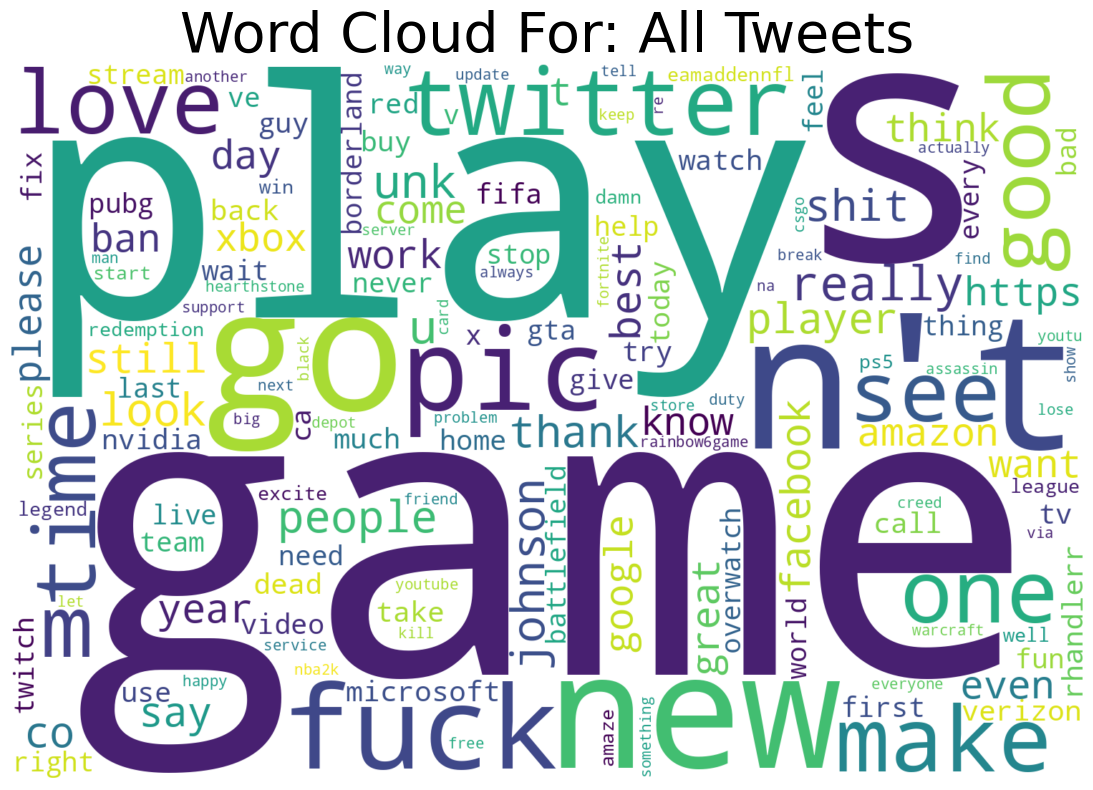

In [38]:
generate_word_cloud(all_text,"All Tweets")

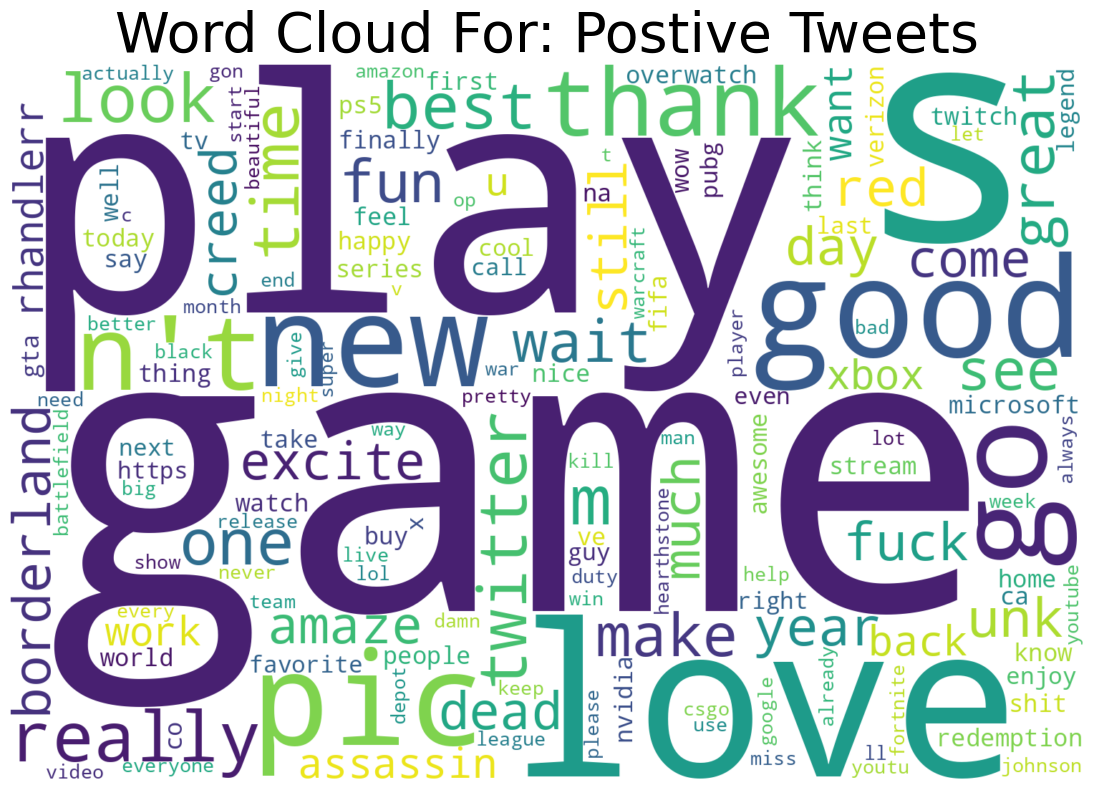

In [39]:
generate_word_cloud(positive_text,"Postive Tweets")

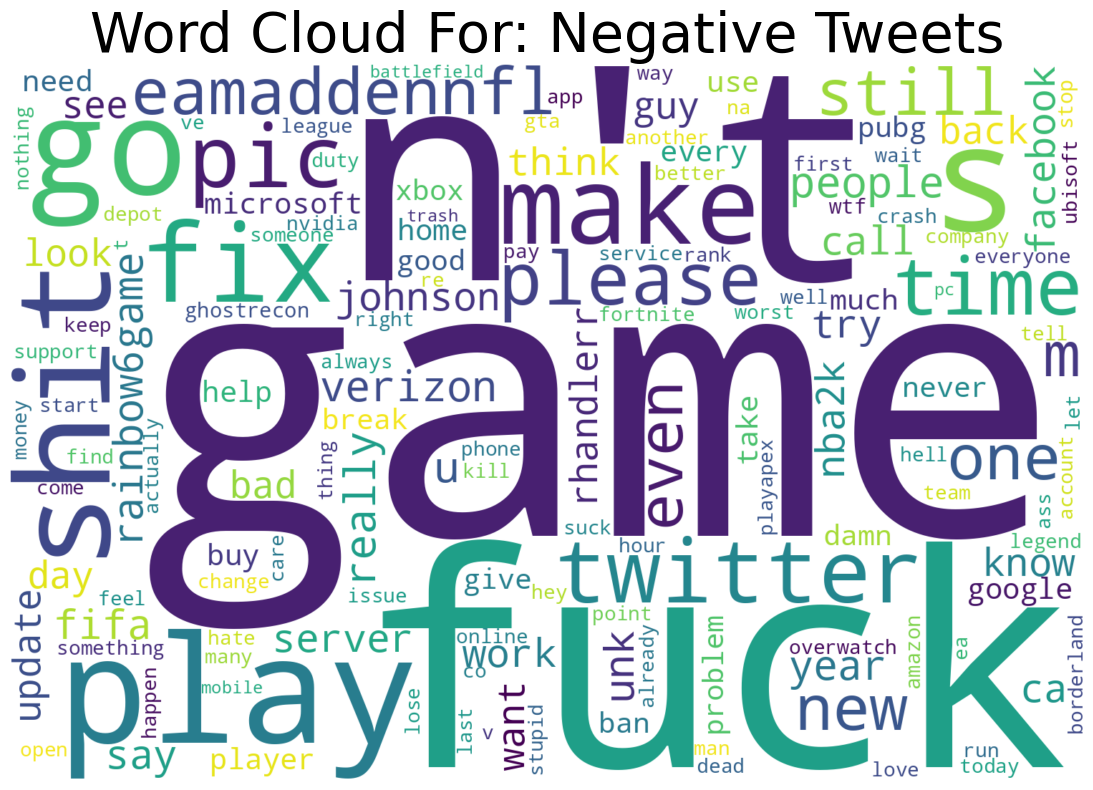

In [40]:
generate_word_cloud(negative_text,"Negative Tweets")

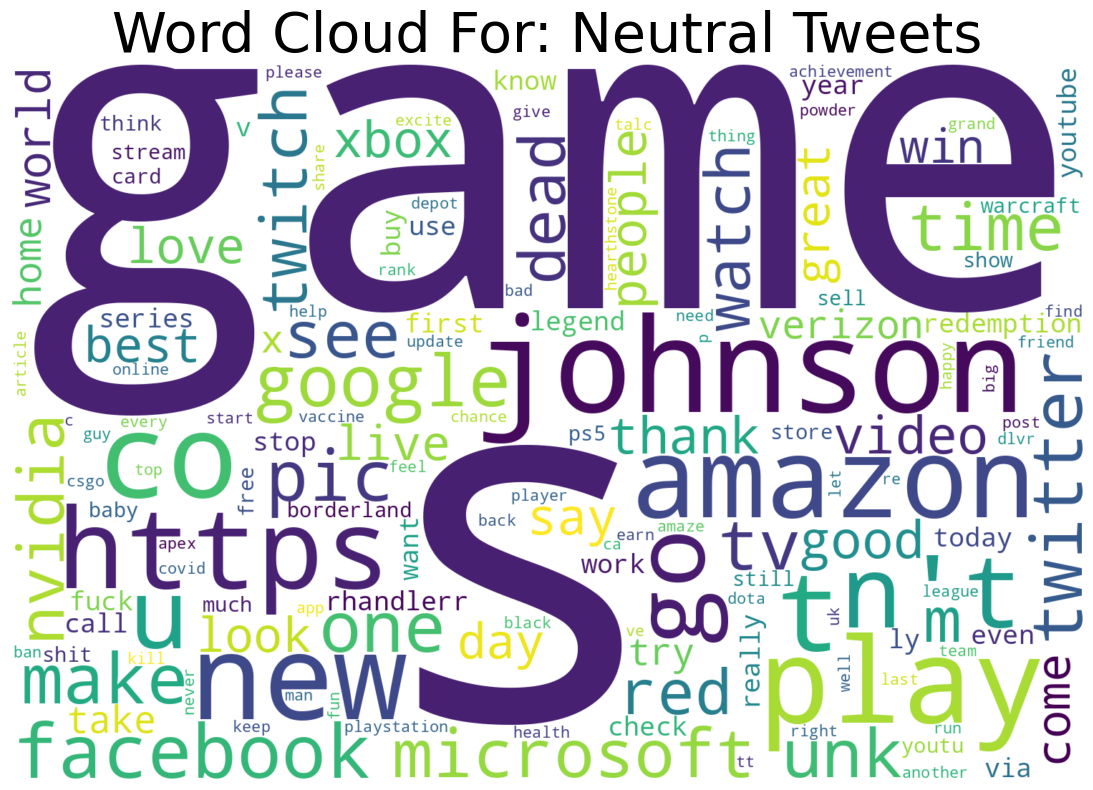

In [41]:
generate_word_cloud(neutral_text,"Neutral Tweets")

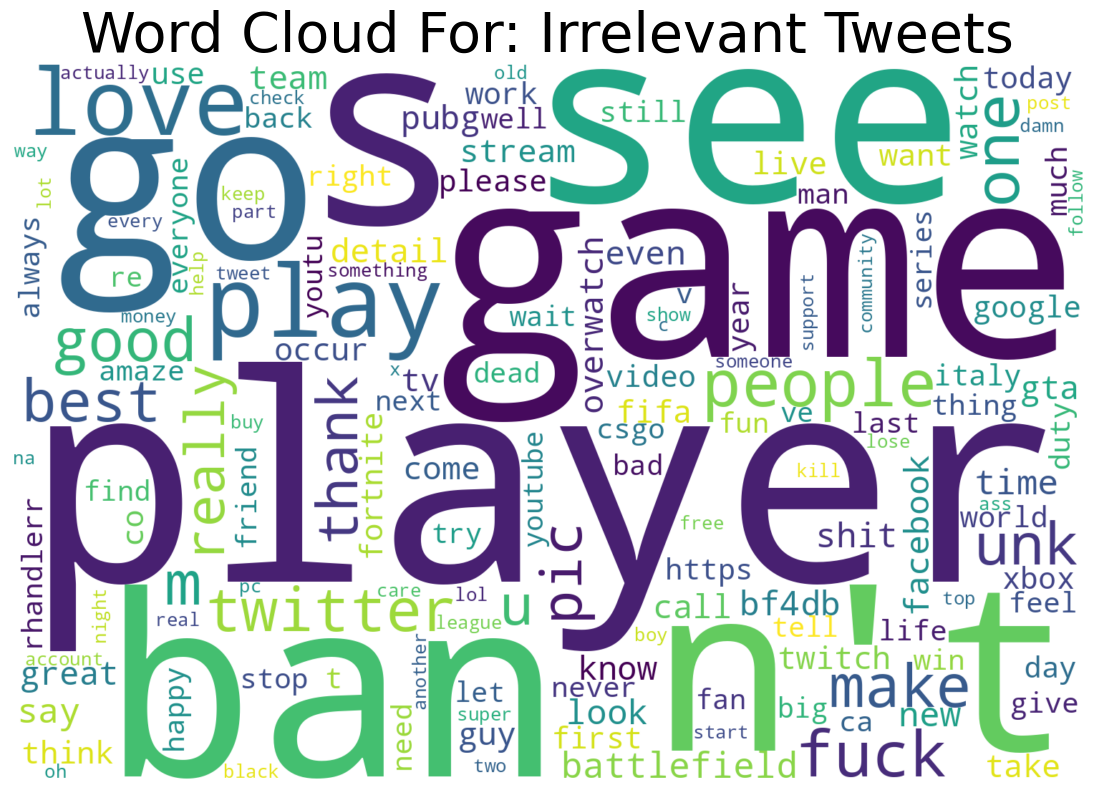

In [42]:
generate_word_cloud(irrelevant_text,"Irrelevant Tweets")

# Preprocessing

## Label Encoding

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

### Encoding mapping

In [44]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

{'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}


In [45]:
sample_df = df.groupby('label').head(2)
sample_df

,id,information,label,tweet,Preprocessed_Text
0,2401,Borderlands,3,im getting on borderlands and i will murder yo...,im get borderlands murder
1,2401,Borderlands,3,I am coming to the borders and I will kill you...,come border kill
12,2403,Borderlands,2,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM...",rock-hard la varlope rare powerful handsome ja...
13,2403,Borderlands,2,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM...",rock-hard la varlope rare powerful handsome ja...
24,2405,Borderlands,1,the biggest dissappoinment in my life came out...,biggest dissappoinment life come year ago fuck...
25,2405,Borderlands,1,The biggest disappointment of my life came a y...,biggest disappointment life come year ago
102,2418,Borderlands,0,Appreciate the (sonic) concepts / praxis Valen...,appreciate sonic concepts praxis valenzuela la...
103,2418,Borderlands,0,Appreciate the (sound) concepts / practices th...,appreciate sound concepts practice valenzuela ...


## Train Test Split

In [46]:
from sklearn.model_selection import train_test_split
X = df[['Preprocessed_Text']]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [47]:
X_train.shape,X_test.shape

((55497, 1), (18499, 1))

In [48]:
y_train.shape,y_test.shape

((55497,), (18499,))

# Feature Engineering

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

## Count Vectorizer

In [50]:
# Unigram
cv = ColumnTransformer(
    [("cv", CountVectorizer(), 'Preprocessed_Text')]
)

# Bigram
cv_bigram = ColumnTransformer(
    [("cv_bigram", CountVectorizer(ngram_range=(2, 2)), 'Preprocessed_Text')]
)

## TF-IDF Vectorizer

In [51]:
# Unigram
tfidf = ColumnTransformer(
    [("tfidf", TfidfVectorizer(), 'Preprocessed_Text')]
)

# Bigram
tfidf_bigram = ColumnTransformer(
    [("tfidf_bigram", TfidfVectorizer(ngram_range=(2, 2)), 'Preprocessed_Text')]
)

## Word to Vector

In [52]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.9 MB/s eta 0:00:00


In [53]:
X_train_tokens = X_train['Preprocessed_Text'].apply(lambda x: x.split()).tolist()
X_test_tokens  = X_test['Preprocessed_Text'].apply(lambda x: x.split()).tolist()

In [54]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=5,
)

In [55]:
def sentence_to_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

In [56]:
X_train_w2v  = np.array([sentence_to_vector(tokens) for tokens in X_train_tokens])
X_test_w2v   = np.array([sentence_to_vector(tokens) for tokens in X_test_tokens])

# Training Model

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

## Random Forest

### Word2Vec

In [58]:
random_forest_wv = RandomForestClassifier(random_state=42, n_jobs=-1)

### Creating the Pipeline

#### Count Vector Pipeline

In [59]:
random_forest_cv = Pipeline([
    ('cv', cv),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_forest_cv_bigram = Pipeline([
    ('cv_bigram', cv_bigram),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

#### TF-IDF Pipeline

In [60]:
random_forest_tfidf = Pipeline([
    ('tfidf', tfidf),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

random_forest_tfidf_bigram = Pipeline([
    ('tfidf_bigram', tfidf_bigram),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

### Fitting the model

In [61]:
random_forest_wv.fit(X_train_w2v, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [62]:
random_forest_cv.fit(X_train, y_train)
random_forest_cv_bigram.fit(X_train, y_train)

Pipeline(steps=[('cv_bigram',
                 ColumnTransformer(transformers=[('cv_bigram',
                                                  CountVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('random_forest',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [63]:
random_forest_tfidf.fit(X_train, y_train)
random_forest_tfidf_bigram.fit(X_train, y_train)

Pipeline(steps=[('tfidf_bigram',
                 ColumnTransformer(transformers=[('tfidf_bigram',
                                                  TfidfVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('random_forest',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

## Naive Bayes

In [64]:
multinomialNB_wv = MultinomialNB()

#### Count Vector Pipeline

In [65]:
multinomialNB_cv = Pipeline([
    ('cv', cv),
    ('multinomialNB', MultinomialNB())
])

multinomialNB_cv_bigram = Pipeline([
    ('cv_bigram', cv_bigram),
    ('multinomialNB', MultinomialNB()),
])

#### TF-IDF Pipeline

In [66]:
multinomialNB_tfidf = Pipeline([
    ('tfidf', tfidf),
    ('multinomialNB', MultinomialNB()),
])

multinomialNB_tfidf_bigram = Pipeline([
    ('tfidf_bigram', tfidf_bigram),
    ('multinomialNB', MultinomialNB()),
])

### Fitting the model

#### Note: MultiNomial NaiveBayes doesn't support negative number so can't be used for word2vec

In [67]:
multinomialNB_cv.fit(X_train, y_train)
multinomialNB_cv_bigram.fit(X_train, y_train)

Pipeline(steps=[('cv_bigram',
                 ColumnTransformer(transformers=[('cv_bigram',
                                                  CountVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('multinomialNB', MultinomialNB())])

In [68]:
multinomialNB_tfidf.fit(X_train, y_train)
multinomialNB_tfidf_bigram.fit(X_train, y_train)

Pipeline(steps=[('tfidf_bigram',
                 ColumnTransformer(transformers=[('tfidf_bigram',
                                                  TfidfVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('multinomialNB', MultinomialNB())])

# Model Evalutation

### Function for diagram

In [69]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score,\
                            confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

result_df = pd.DataFrame(
    columns=["model name", "accuracy", "precision", "recall", "f1"]
)

def save_result(y_pred, title):
    accuracy = np.round(accuracy_score(y_test, y_pred), 2)
    precision = np.round(precision_score(y_test, y_pred, average="weighted"), 2)
    recall = np.round(recall_score(y_test, y_pred, average="weighted"), 2)
    f1 = np.round(f1_score(y_test, y_pred, average="weighted"), 2)

    result_df.loc[len(result_df)] = [title, accuracy, precision, recall, f1]

# Confusion Matrix
def display_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix for {title}")
    plt.tight_layout()
    plt.show()

# ROC Curve
def display_ROC(y_test, y_prob, classes_, title):
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=classes_)
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve for {title}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Function for displaying some predictions

In [70]:
def display_prediction(model,title= "Model"):
    sentence1 = "This new feature is a game changer, I love using this new feature"
    sentence2 = "This update is awful and ruined my workflow completely"

    data1 = pd.DataFrame({'Preprocessed_Text': [sentence1]})
    data2 = pd.DataFrame({'Preprocessed_Text': [sentence2]})

    # Predictions
    pred1 = model.predict(data1)
    pred2 = model.predict(data2)
    # Decode numeric labels to text
    decoded1 = le.inverse_transform(pred1)
    decoded2 = le.inverse_transform(pred2)
    print(f"Sentence is:\n{sentence1}\nPrediction by {title} is {decoded1[0]}")
    print(f"Sentence is:\n{sentence2}\nPrediction by {title} is {decoded2[0]}")

In [71]:
from sklearn.metrics import classification_report

def generate_evaluation(model, X_test, is_prediction = True, title=""):
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)

  print(f"{title} Evaluation:\n")
  print(f"Classification Report:")
  print(classification_report(y_test, y_pred))
  print("\n")
  save_result(y_pred, title)
  display_confusion_matrix(y_test, y_pred, title=title)
  display_ROC(y_test, y_prob, model.classes_, title=title)
  if is_prediction:
    display_prediction(model,title)

## Word2Vec Random Forest

Random Forest Word2Vec Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.55      0.65      3219
           1       0.74      0.82      0.78      5589
           2       0.74      0.68      0.71      4527
           3       0.69      0.79      0.74      5164

    accuracy                           0.73     18499
   macro avg       0.74      0.71      0.72     18499
weighted avg       0.74      0.73      0.73     18499





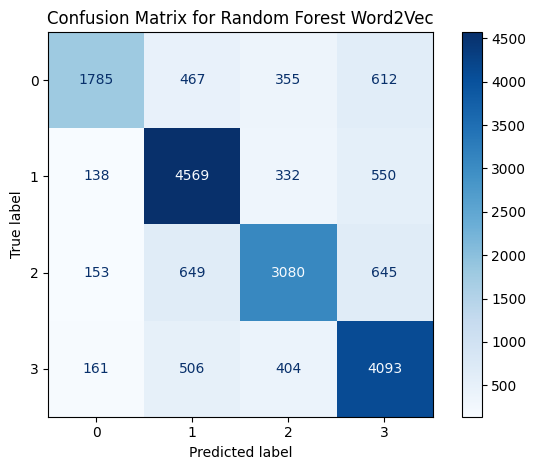

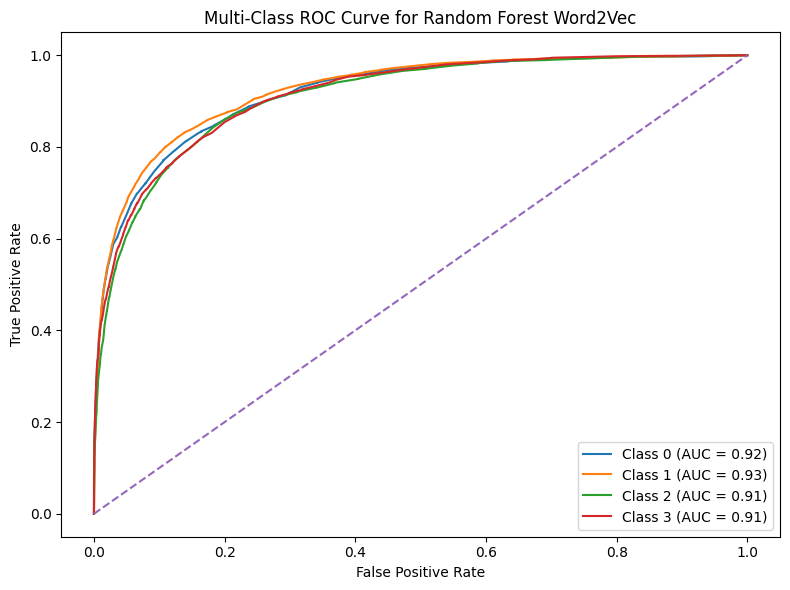

In [72]:
generate_evaluation(model=random_forest_wv, X_test=X_test_w2v, is_prediction=False, title="Random Forest Word2Vec")

In [73]:
sentence1 = "This new feature is a game changer, I love using this new feature"
sentence2 = "This update is awful and ruined my workflow completely"

sentence1_vec = sentence_to_vector(sentence1.split())
sentence2_vec = sentence_to_vector(sentence2.split())
# Predictions
pred1 = random_forest_wv.predict([sentence1_vec])
pred2 = random_forest_wv.predict([sentence2_vec])
# Decode numeric labels to text
decoded1 = le.inverse_transform(pred1)
decoded2 = le.inverse_transform(pred2)
print(f"Sentence is:\n{sentence1}\nPrediction by Random Forest Word2Vec is {decoded1[0]}\n")
print(f"Sentence is:\n{sentence2}\nPrediction by Random Forest Word2Vec is {decoded2[0]}\n")

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest Word2Vec is Positive

Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest Word2Vec is Negative



## Count Random Forest

Random Forest Count Vectorizer (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      3219
           1       0.92      0.93      0.93      5589
           2       0.88      0.92      0.90      4527
           3       0.90      0.92      0.91      5164

    accuracy                           0.91     18499
   macro avg       0.92      0.91      0.91     18499
weighted avg       0.91      0.91      0.91     18499





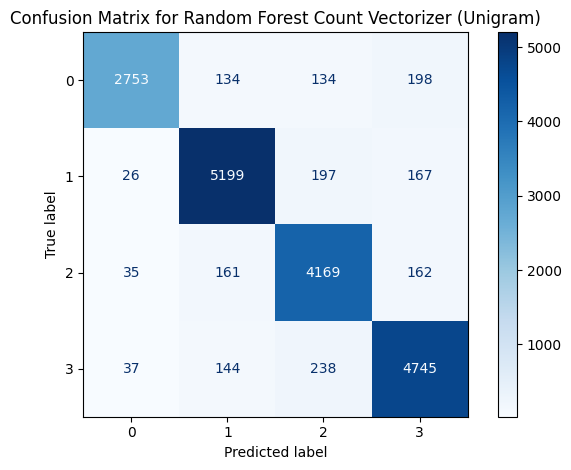

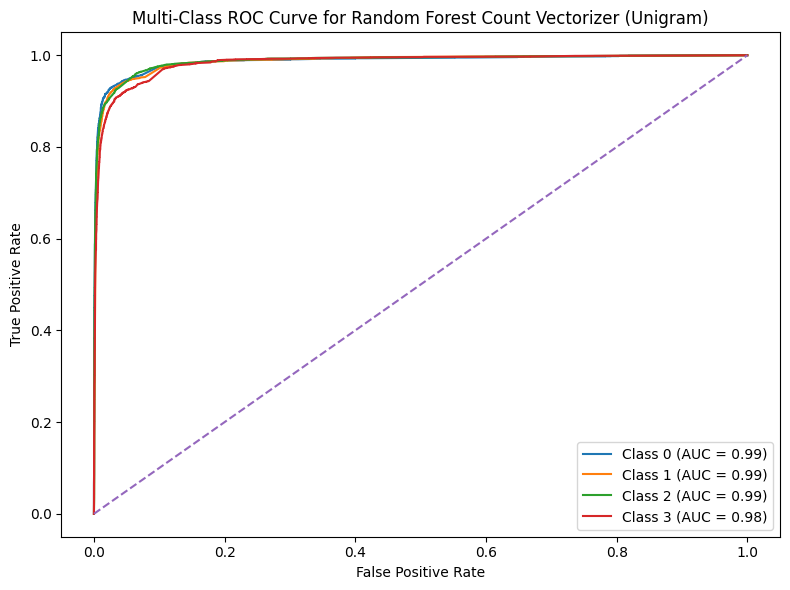

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest Count Vectorizer (Unigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest Count Vectorizer (Unigram) is Negative


In [74]:
generate_evaluation(model=random_forest_cv, X_test=X_test, title="Random Forest Count Vectorizer (Unigram)")

Random Forest Count Vectorizer (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      3219
           1       0.90      0.83      0.86      5589
           2       0.90      0.83      0.86      4527
           3       0.72      0.92      0.81      5164

    accuracy                           0.84     18499
   macro avg       0.87      0.83      0.84     18499
weighted avg       0.86      0.84      0.85     18499





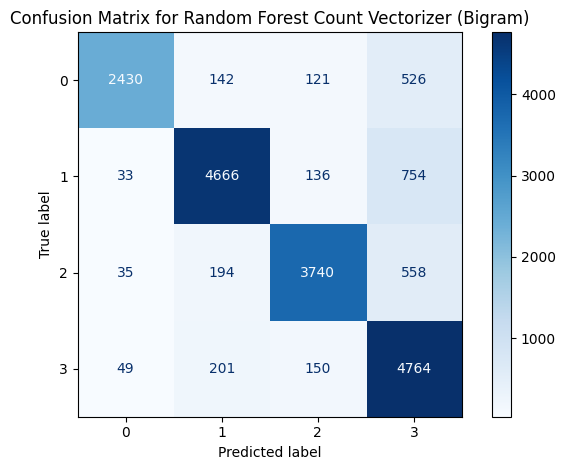

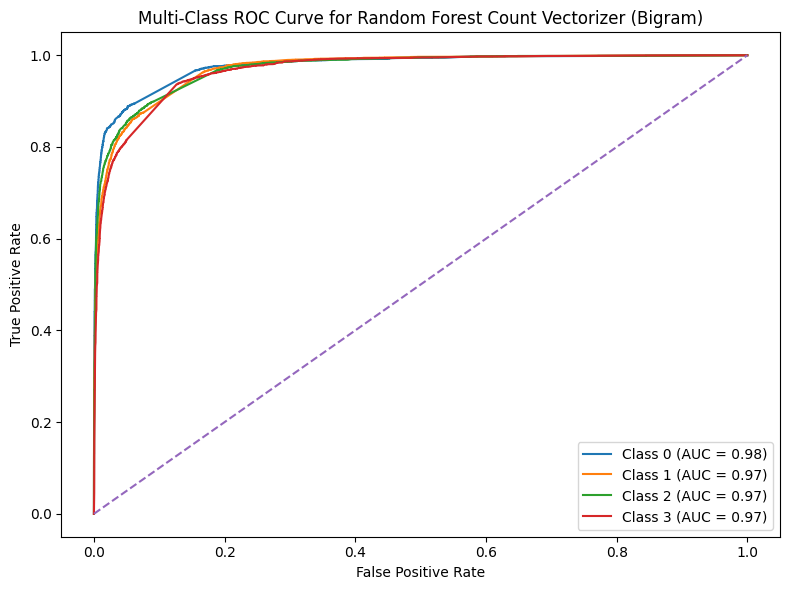

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest Count Vectorizer (Bigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest Count Vectorizer (Bigram) is Positive


In [75]:
generate_evaluation(model=random_forest_cv_bigram, X_test=X_test, title="Random Forest Count Vectorizer (Bigram)")

## TF-IDF Random Forest

Random Forest TF-IDF (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      3219
           1       0.92      0.93      0.93      5589
           2       0.88      0.92      0.90      4527
           3       0.90      0.92      0.91      5164

    accuracy                           0.91     18499
   macro avg       0.92      0.91      0.91     18499
weighted avg       0.92      0.91      0.91     18499





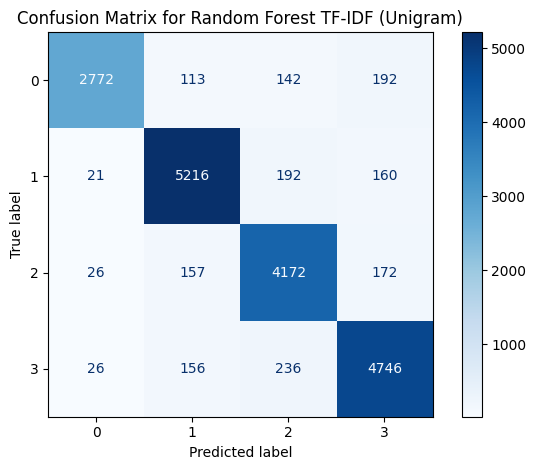

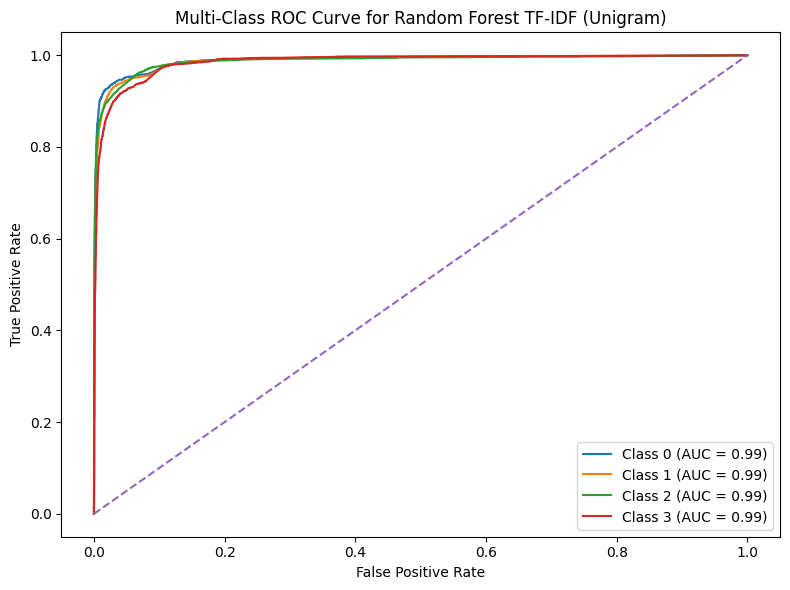

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest TF-IDF (Unigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest TF-IDF (Unigram) is Negative


In [76]:
generate_evaluation(model=random_forest_tfidf, X_test=X_test, title="Random Forest TF-IDF (Unigram)")

Random Forest TF-IDF (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      3219
           1       0.90      0.83      0.86      5589
           2       0.90      0.83      0.86      4527
           3       0.72      0.93      0.81      5164

    accuracy                           0.84     18499
   macro avg       0.87      0.83      0.84     18499
weighted avg       0.86      0.84      0.84     18499





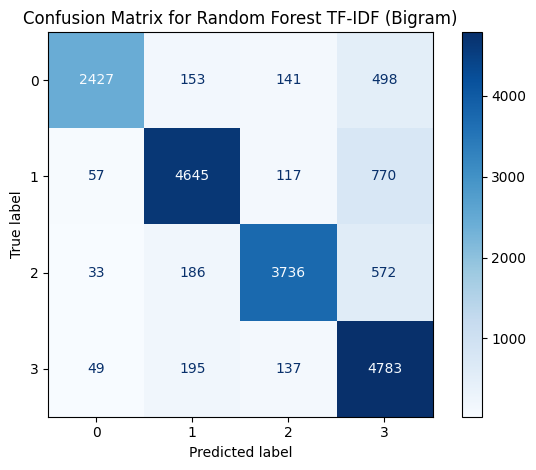

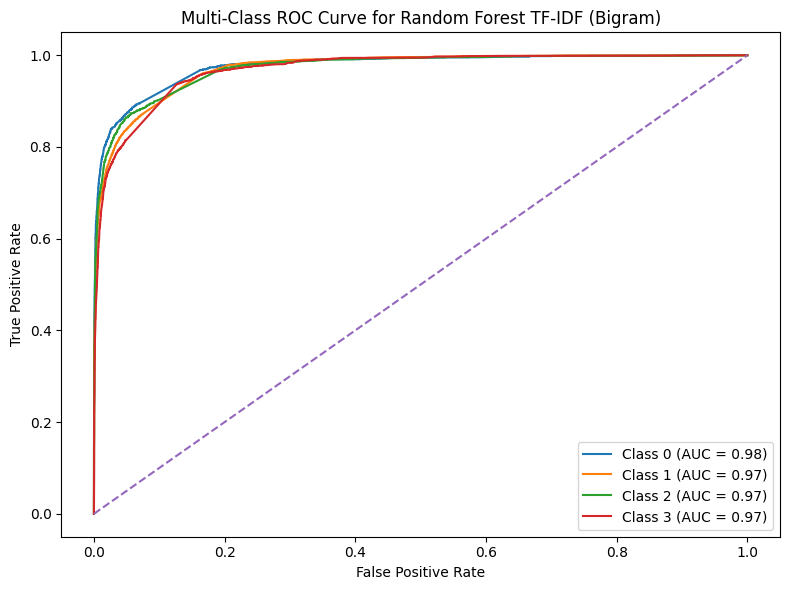

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest TF-IDF (Bigram) is Irrelevant
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest TF-IDF (Bigram) is Positive


In [77]:
generate_evaluation(model=random_forest_tfidf_bigram, X_test=X_test, title="Random Forest TF-IDF (Bigram)")

## Count Vectorizer MultiNomial NaiveBayes

Naive Bayes Count Vectorizer (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.62      0.71      3219
           1       0.69      0.85      0.76      5589
           2       0.81      0.64      0.71      4527
           3       0.72      0.79      0.76      5164

    accuracy                           0.74     18499
   macro avg       0.76      0.73      0.74     18499
weighted avg       0.75      0.74      0.74     18499





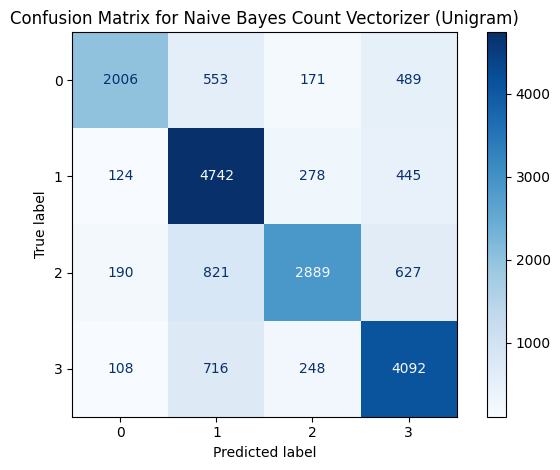

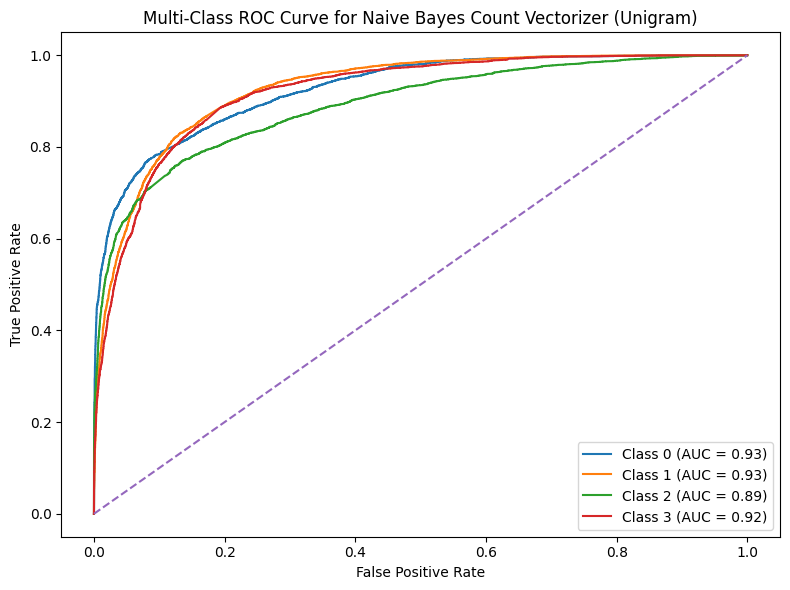

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes Count Vectorizer (Unigram) is Neutral
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes Count Vectorizer (Unigram) is Negative


In [78]:
generate_evaluation(model=multinomialNB_cv, X_test=X_test, title="Naive Bayes Count Vectorizer (Unigram)")

Naive Bayes Count Vectorizer (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      3219
           1       0.81      0.96      0.88      5589
           2       0.95      0.89      0.92      4527
           3       0.92      0.86      0.89      5164

    accuracy                           0.89     18499
   macro avg       0.91      0.89      0.90     18499
weighted avg       0.90      0.89      0.90     18499





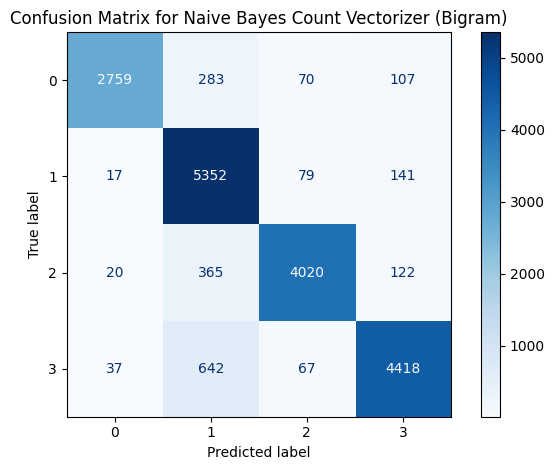

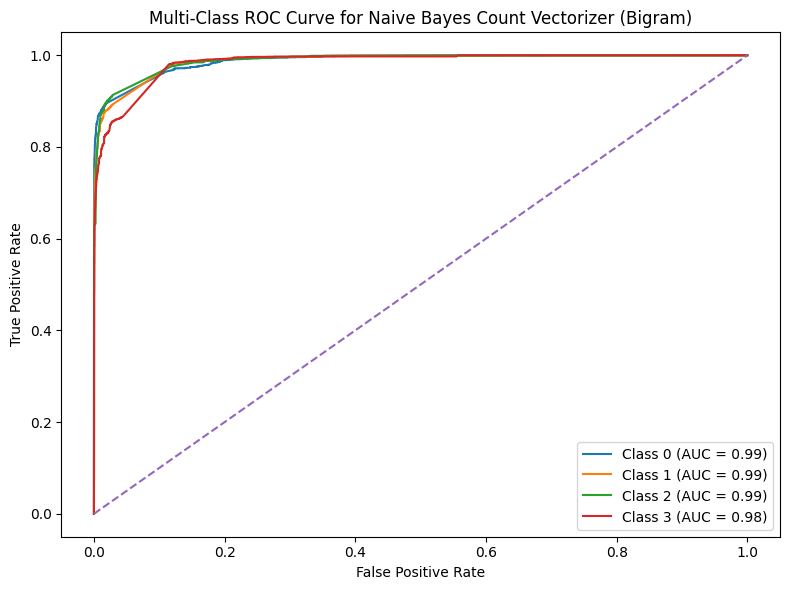

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes Count Vectorizer (Bigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes Count Vectorizer (Bigram) is Negative


In [79]:
generate_evaluation(model=multinomialNB_cv_bigram, X_test=X_test, title="Naive Bayes Count Vectorizer (Bigram)")

## TF-IDF MultiNomial NaiveBayes

Naive Bayes TF-IDF (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.43      0.59      3219
           1       0.65      0.90      0.75      5589
           2       0.83      0.62      0.71      4527
           3       0.70      0.81      0.75      5164

    accuracy                           0.72     18499
   macro avg       0.78      0.69      0.70     18499
weighted avg       0.76      0.72      0.71     18499





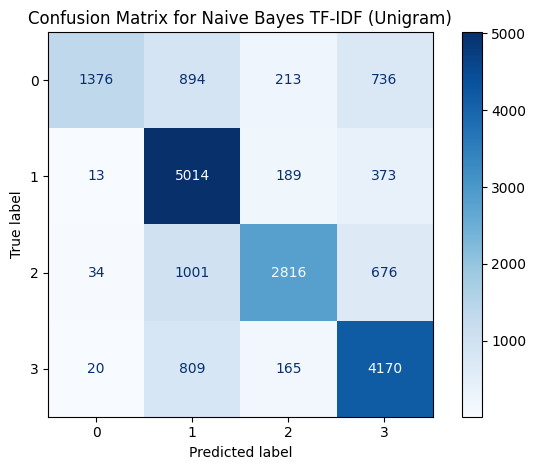

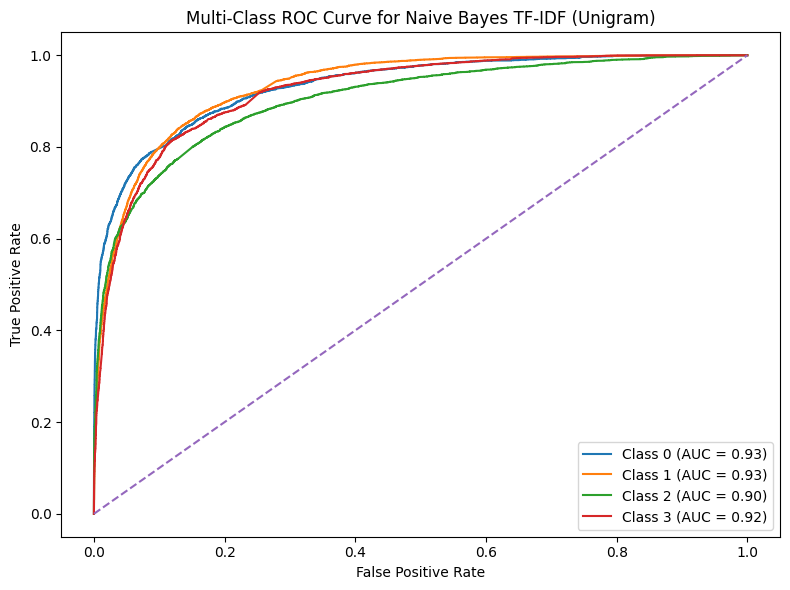

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes TF-IDF (Unigram) is Neutral
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes TF-IDF (Unigram) is Negative


In [80]:
generate_evaluation(model=multinomialNB_tfidf, X_test=X_test, title="Naive Bayes TF-IDF (Unigram)")

Naive Bayes TF-IDF (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      3219
           1       0.79      0.97      0.87      5589
           2       0.95      0.87      0.91      4527
           3       0.91      0.86      0.88      5164

    accuracy                           0.88     18499
   macro avg       0.91      0.87      0.89     18499
weighted avg       0.90      0.88      0.88     18499





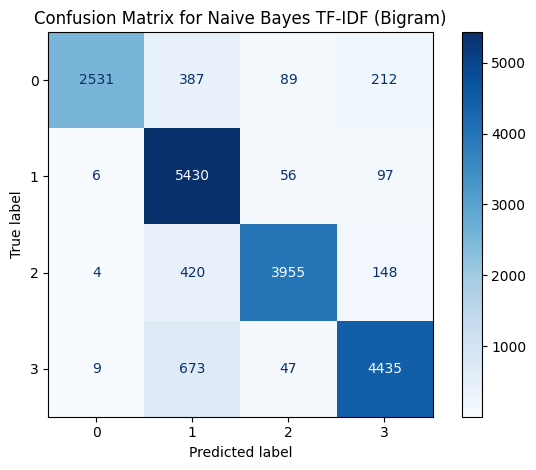

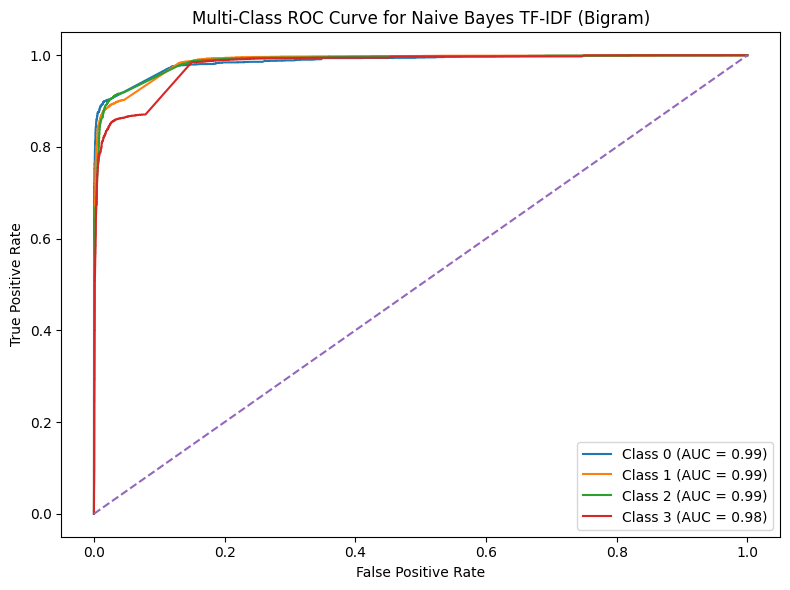

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes TF-IDF (Bigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes TF-IDF (Bigram) is Negative


In [81]:
generate_evaluation(model=multinomialNB_tfidf_bigram, X_test=X_test, title="Naive Bayes TF-IDF (Bigram)")

# Result

In [82]:
result_df = result_df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)
result_df

,model name,accuracy,precision,recall,f1
0,Random Forest Count Vectorizer (Unigram),0.91,0.91,0.91,0.91
1,Random Forest TF-IDF (Unigram),0.91,0.92,0.91,0.91
2,Naive Bayes Count Vectorizer (Bigram),0.89,0.90,0.89,0.90
3,Naive Bayes TF-IDF (Bigram),0.88,0.90,0.88,0.88
4,Random Forest TF-IDF (Bigram),0.84,0.86,0.84,0.84
5,Random Forest Count Vectorizer (Bigram),0.84,0.86,0.84,0.85
6,Naive Bayes Count Vectorizer (Unigram),0.74,0.75,0.74,0.74
7,Random Forest Word2Vec,0.73,0.74,0.73,0.73
8,Naive Bayes TF-IDF (Unigram),0.72,0.76,0.72,0.71


## Model Performance Comparison

In [83]:
def labels(ax):
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v * 100:.2f}" for v in container.datavalues], padding=3)

def generate_performance_bar(df, title="Model Performance Comparison"):
    metrics = ['recall', 'precision', 'f1', 'accuracy']

    fig, axs = plt.subplots(4, 1, figsize=(14, 14))

    for i, metric in enumerate(metrics):
        df = df.sort_values(by=metric, ascending=False)
        ax = sns.barplot(x=metric, y="model name", hue="model name", legend=False, data=df, palette="Blues_d", ax=axs[i])
        ax.set_xlabel("")
        ax.set_title(metric.capitalize())
        labels(ax)
    plt.suptitle(title, y=1)
    plt.tight_layout()
    plt.show()

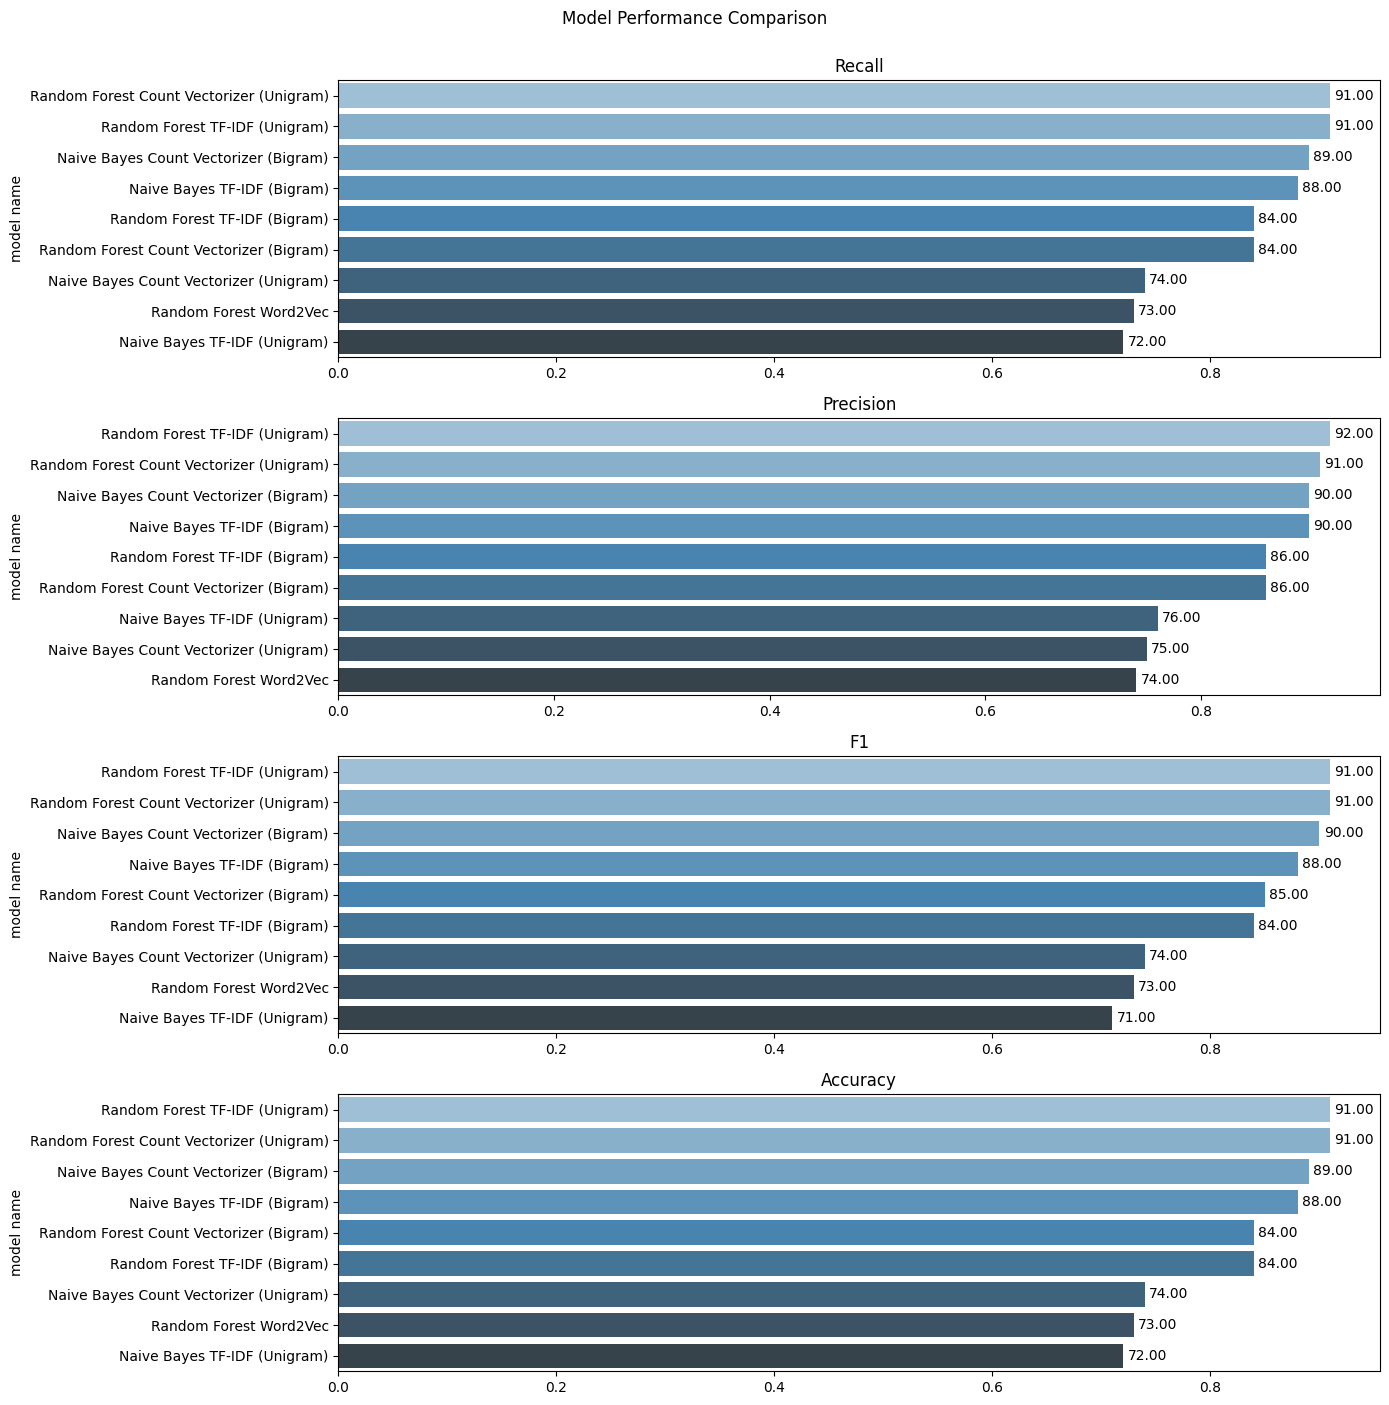

In [84]:
generate_performance_bar(result_df)